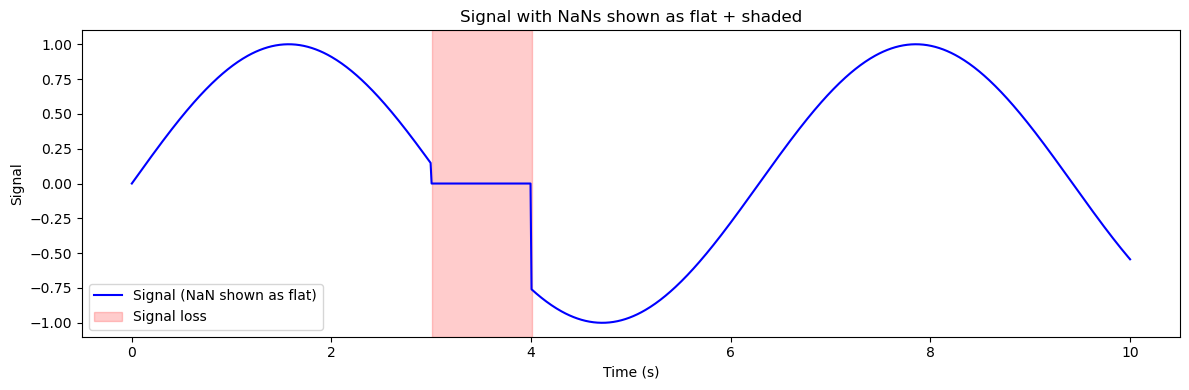

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example signal with NaNs
fs = 100  # Hz
t = np.linspace(0, 10, fs * 10)
signal = np.sin(t)
signal[300:400] = np.nan  # Inject signal loss

# Replace NaNs with a flat value (e.g., the last valid value or 0)
flat_signal = signal.copy()
nan_mask = np.isnan(flat_signal)
flat_signal[nan_mask] = 0  # or np.nanmean(signal), or a constant like -999

# Plot the main signal
plt.figure(figsize=(12, 4))
plt.plot(t, flat_signal, label="Signal (NaN shown as flat)", color='blue')

# Shade the NaN regions
in_nan = False
for i in range(len(signal)):
    if nan_mask[i] and not in_nan:
        start = t[i]
        in_nan = True
    elif not nan_mask[i] and in_nan:
        end = t[i]
        in_nan = False
        plt.axvspan(start, end, color='red', alpha=0.2, label="Signal loss" if 'Signal loss' not in plt.gca().get_legend_handles_labels()[1] else "")

# Optional: close final span if ends in NaN
if in_nan:
    plt.axvspan(start, t[-1], color='red', alpha=0.2)

plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Signal with NaNs shown as flat + shaded")
plt.legend()
plt.tight_layout()
plt.show()
